# CC3092 — Laboratorio 8: Mini-GPT con muestreo controlado

Se entrena un Mini-GPT a nivel de carácter sobre `tiny_shakespeare`, se implementan desde cero las estrategias de muestreo (greedy, top-k con temperatura, top-p con temperatura) y se generan las muestras pedidas.


In [1]:
import math
import os
import time
import urllib.request

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(1337)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cpu


## Task 1.1 — Dataset, vocabulario y batches

In [2]:
DATA_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATA_PATH = "data/input.txt"
os.makedirs("data", exist_ok=True)

if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

with open(DATA_PATH, "r", encoding="utf-8") as f:
    text = f.read()

print(f"Longitud del texto: {len(text):,} caracteres")
print(text[:200])


Longitud del texto: 1,115,394 caracteres
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [3]:
# Vocabulario de caracteres únicos y mappings bidireccionales char <-> índice.
chars = sorted(set(text))
vocab_size = len(chars)
assert vocab_size == 65, f"Se esperaban 65 caracteres, se obtuvieron {vocab_size}"

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}


def encode(s: str) -> list[int]:
    return [stoi[c] for c in s]


def decode(ids) -> str:
    return "".join(itos[int(i)] for i in ids)


print(f"vocab_size = {vocab_size}")
print("".join(chars))


vocab_size = 65

 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


In [4]:
# Codificación completa y split 90/10 respetando el orden temporal (sin shuffle).
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print(f"train tokens: {len(train_data):,}  val tokens: {len(val_data):,}")


train tokens: 1,003,854  val tokens: 111,540


In [5]:
block_size = 128
d_model = 128
n_heads = 4
n_layers = 3
batch_size = 64
lr = 3e-4
epochs = 10


In [6]:
def get_batch(split: str) -> tuple[torch.Tensor, torch.Tensor]:
    """Arma un batch [batch_size, block_size]. Y es X desplazado un paso al futuro,
    la factorización autoregresiva estándar de un LM causal."""
    source = train_data if split == "train" else val_data
    ix = torch.randint(0, len(source) - block_size - 1, (batch_size,))
    x = torch.stack([source[i:i + block_size] for i in ix])
    y = torch.stack([source[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)


xb, yb = get_batch("train")
assert xb.shape == yb.shape == (batch_size, block_size)
assert torch.equal(xb[:, 1:], yb[:, :-1])
print("batch shapes ok:", xb.shape, yb.shape)


batch shapes ok: torch.Size([64, 128]) torch.Size([64, 128])


## Task 1.2 — Mini-GPT (decoder-only) y entrenamiento

In [7]:
def causal_mask(length: int, device) -> torch.Tensor:
    # Máscara booleana triangular superior: True = posición bloqueada (futuro).
    # Impide que la posición s atienda a tokens s+1, s+2, ... (factorización autoregresiva).
    return torch.triu(
        torch.ones(length, length, dtype=torch.bool, device=device),
        diagonal=1,
    )


class MiniGPT(nn.Module):
    """Decoder-only: embedding de token + posición, bloques Transformer con
    self-attention causal, y una cabeza lineal que proyecta al vocabulario."""

    def __init__(self, vocab_size, d_model, n_heads, n_layers, block_size):
        super().__init__()
        self.block_size = block_size
        self.token = nn.Embedding(vocab_size, d_model)
        self.pos = nn.Embedding(block_size, d_model)
        layer = nn.TransformerEncoderLayer(
            d_model, n_heads, dim_feedforward=4 * d_model,
            dropout=0.1, batch_first=True, norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, ids: torch.Tensor) -> torch.Tensor:
        B, T = ids.shape
        positions = torch.arange(T, device=ids.device)
        x = self.token(ids) + self.pos(positions)[None]
        # attn_mask causal: cada posición solo ve el prefijo permitido.
        x = self.blocks(x, mask=causal_mask(T, ids.device), is_causal=True)
        x = self.ln_f(x)
        return self.lm_head(x)  # [B, T, vocab_size]


model = MiniGPT(vocab_size, d_model, n_heads, n_layers, block_size).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"parámetros entrenables: {n_params:,}")


parámetros entrenables: 628,096


In [8]:
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

# Un "epoch" recorre aproximadamente todo train_data una vez en bloques de batch_size*block_size.
steps_per_epoch = len(train_data) // (batch_size * block_size)
val_eval_batches = 20
print(f"steps_per_epoch = {steps_per_epoch}")


@torch.no_grad()
def estimate_val_loss() -> float:
    model.eval()
    losses = []
    for _ in range(val_eval_batches):
        x, y = get_batch("val")
        logits = model(x)
        loss = F.cross_entropy(logits.reshape(-1, vocab_size), y.reshape(-1))
        losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)


steps_per_epoch = 122


In [9]:
history = {"train": [], "val": []}
t0 = time.time()

for epoch in range(epochs):
    epoch_losses = []
    for step in range(steps_per_epoch):
        x, y = get_batch("train")
        logits = model(x)
        # Cross-entropy por token: L_t = -log p(x_{t+1} | x_{<=t}).
        loss = F.cross_entropy(logits.reshape(-1, vocab_size), y.reshape(-1))
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())

    train_loss = sum(epoch_losses) / len(epoch_losses)
    val_loss = estimate_val_loss()
    history["train"].append(train_loss)
    history["val"].append(val_loss)
    print(f"epoch {epoch + 1:2d}/{epochs}  train_loss={train_loss:.4f}  "
          f"val_loss={val_loss:.4f}  elapsed={time.time() - t0:.1f}s")


epoch  1/10  train_loss=2.9947  val_loss=2.6340  elapsed=119.8s
epoch  2/10  train_loss=2.5678  val_loss=2.5155  elapsed=226.7s
epoch  3/10  train_loss=2.4935  val_loss=2.4556  elapsed=329.5s
epoch  4/10  train_loss=2.4389  val_loss=2.3995  elapsed=433.6s
epoch  5/10  train_loss=2.3711  val_loss=2.3180  elapsed=536.5s
epoch  6/10  train_loss=2.2947  val_loss=2.2337  elapsed=639.6s
epoch  7/10  train_loss=2.2215  val_loss=2.1632  elapsed=742.3s
epoch  8/10  train_loss=2.1608  val_loss=2.1137  elapsed=844.2s
epoch  9/10  train_loss=2.1050  val_loss=2.0730  elapsed=945.7s
epoch 10/10  train_loss=2.0615  val_loss=2.0360  elapsed=1049.0s


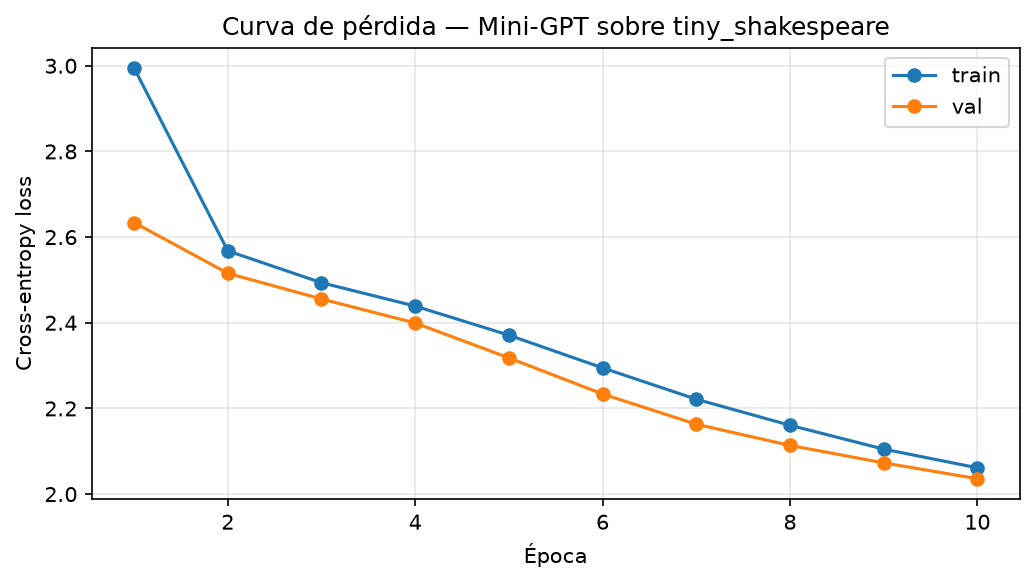

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), history["train"], marker="o", label="train")
plt.plot(range(1, epochs + 1), history["val"], marker="o", label="val")
plt.xlabel("Época")
plt.ylabel("Cross-entropy loss")
plt.title("Curva de pérdida — Mini-GPT sobre tiny_shakespeare")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()


In [11]:
@torch.no_grad()
def full_val_perplexity() -> float:
    """Perplejidad = exp((1/N) * sum_t L_t), con L_t la cross-entropy en el
    token t, evaluada sobre bloques no solapados de TODO el split de validación."""
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    n_val = len(val_data)
    for i in range(0, n_val - block_size - 1, block_size):
        x = val_data[i:i + block_size].unsqueeze(0).to(device)
        y = val_data[i + 1:i + block_size + 1].unsqueeze(0).to(device)
        logits = model(x)
        loss = F.cross_entropy(
            logits.reshape(-1, vocab_size), y.reshape(-1), reduction="sum"
        )
        total_loss += loss.item()
        total_tokens += y.numel()
    model.train()
    mean_loss = total_loss / total_tokens  # (1/N) * sum_t L_t
    return math.exp(mean_loss)


val_perplexity = full_val_perplexity()
print(f"Perplejidad de validación: {val_perplexity:.3f}")
assert 3.5 <= val_perplexity <= 8.0, "Perplejidad fuera del rango esperado (3.5-8.0)"


Perplejidad de validación: 7.649


## Task 1.3 — Muestreo desde cero (greedy, top-k, top-p)

In [ ]:
def sample_greedy(logits: torch.Tensor) -> int:
    """Greedy: argmax(z_i), sin aleatoriedad."""
    return int(torch.argmax(logits).item())


def sample_top_k(logits: torch.Tensor, k: int, tau: float) -> int:
    """Top-k con temperatura:
    1) z' = z / tau  (softmax con temperatura: P_tau(i) = softmax(z_i/tau))
    2) conservar los k logits más altos, el resto -> -inf
    3) softmax y muestrear categóricamente.
    """
    scaled = logits / tau
    k = min(k, scaled.numel())
    threshold = torch.topk(scaled, k).values[-1]
    filtered = torch.where(scaled < threshold, torch.full_like(scaled, float("-inf")), scaled)
    probs = torch.softmax(filtered, dim=-1)
    return int(torch.multinomial(probs, num_samples=1).item())


def sample_top_p(logits: torch.Tensor, p: float, tau: float) -> int:
    """Top-p / nucleus con temperatura:
    1) z' = z / tau, softmax -> P_tau(i)
    2) ordenar de mayor a menor, incluir tokens hasta que la prob. acumulada supere p
       (conjunto S_p tal que sum_{i in S_p} P(i) >= p)
    3) renormalizar dentro de S_p: P_S(i) = P(i)*1[i in S_p] / sum_{j in S_p} P(j)
    4) muestrear categóricamente.
    """
    probs = torch.softmax(logits / tau, dim=-1)
    sorted_probs, sorted_idx = torch.sort(probs, descending=True)
    cumulative = sorted_probs.cumsum(dim=-1)
    # cumulative - sorted_probs = masa acumulada ANTES de incluir el token i
    # si ya superó p antes de sumar i, entonces i queda fuera del núcleo.
    remove = cumulative - sorted_probs >= p
    sorted_probs[remove] = 0.0
    sorted_probs = sorted_probs / sorted_probs.sum()  # renormalización truncada
    choice = torch.multinomial(sorted_probs, num_samples=1)
    return int(sorted_idx[choice].item())


In [13]:
# Sanity checks rápidos sobre logits sintéticos.
demo_logits = torch.tensor([5.0, 4.1, 3.5, 2.4, 0.1])
assert sample_greedy(demo_logits) == 0

g_counts = {}
for _ in range(200):
    idx = sample_top_k(demo_logits, k=2, tau=0.7)
    g_counts[idx] = g_counts.get(idx, 0) + 1
assert set(g_counts.keys()).issubset({0, 1}), "top_k=2 no debería salir de los 2 mejores logits"

p_counts = set()
for _ in range(200):
    p_counts.add(sample_top_p(demo_logits, p=0.5, tau=1.0))
print("top_k=2 counts:", g_counts)
print("top_p=0.5 índices vistos:", p_counts)


top_k=2 counts: {0: 156, 1: 44}
top_p=0.5 índices vistos: {0}


## Task 2.1 — `generate()` y las 5 configuraciones pedidas

In [14]:
@torch.no_grad()
def generate(prompt: str, max_new_tokens: int, strategy: str, **kwargs) -> str:
    """Genera texto carácter a carácter de forma autoregresiva.

    strategy: "greedy" | "top_k" | "top_p"
    kwargs: parámetros de la estrategia elegida (k, tau, p).
    """
    model.eval()
    ids = encode(prompt)
    for _ in range(max_new_tokens):
        context = torch.tensor([ids[-block_size:]], dtype=torch.long, device=device)
        logits = model(context)
        last_logits = logits[0, -1, :]  # logits del siguiente token

        if strategy == "greedy":
            next_id = sample_greedy(last_logits)
        elif strategy == "top_k":
            next_id = sample_top_k(last_logits, k=kwargs["k"], tau=kwargs["tau"])
        elif strategy == "top_p":
            next_id = sample_top_p(last_logits, p=kwargs["p"], tau=kwargs["tau"])
        else:
            raise ValueError(f"strategy desconocida: {strategy}")

        ids.append(next_id)

    model.train()
    return decode(ids)


In [15]:
configs = {
    "A": dict(strategy="greedy", kwargs={}),
    "B": dict(strategy="top_k", kwargs=dict(k=5, tau=0.7)),
    "C": dict(strategy="top_k", kwargs=dict(k=50, tau=1.0)),
    "D": dict(strategy="top_p", kwargs=dict(p=0.70, tau=0.7)),
    "E": dict(strategy="top_p", kwargs=dict(p=0.95, tau=1.0)),
}

prompt = "ROMEO:"
n_samples = 5
n_chars = 200

samples = {name: [] for name in configs}
for name, cfg in configs.items():
    for _ in range(n_samples):
        text_out = generate(prompt, n_chars, cfg["strategy"], **cfg["kwargs"])
        samples[name].append(text_out)

for name, cfg in configs.items():
    print("=" * 70)
    print(f"Config {name} — {cfg['strategy']} {cfg['kwargs']}")
    print("=" * 70)
    for i, s in enumerate(samples[name], 1):
        print(f"--- muestra {i} ---")
        print(s)
        print()


Config A — greedy {}
--- muestra 1 ---
ROMEO:
What the the the the the so so so the the the sone
And the shat the so the the the stere the the the she so son
The shat the the shat the the she so she the so sone the so sone
The shat the the she s

--- muestra 2 ---
ROMEO:
What the the the the the so so so the the the sone
And the shat the so the the the stere the the the she so son
The shat the the shat the the she so she the so sone the so sone
The shat the the she s

--- muestra 3 ---
ROMEO:
What the the the the the so so so the the the sone
And the shat the so the the the stere the the the she so son
The shat the the shat the the she so she the so sone the so sone
The shat the the she s

--- muestra 4 ---
ROMEO:
What the the the the the so so so the the the sone
And the shat the so the the the stere the the the she so son
The shat the the shat the the she so she the so sone the so sone
The shat the the she s

--- muestra 5 ---
ROMEO:
What the the the the the so so so the the the sone

## Task 2.2 — Respuestas

### a. Repetición/ciclos en greedy (Configuración A)

Las 5 muestras de la configuración A son **idénticas entre sí, carácter por carácter**:

```
ROMEO:
What the the the the the so so so the the the sone
And the shat the so the the the stere the the the she so son
The shat the the shat the the she so she the so sone the so sone
The shat the the she s
```

El muestreo greedy se define como $\hat{x}_{t+1} = \arg\max_i z_i$: en cada paso se elige, sin ningún componente aleatorio, el token de mayor logit. Como la función `argmax` es determinista y el contexto de entrada en cada paso es exactamente la secuencia generada hasta ese momento, dos ejecuciones con el mismo prompt producen siempre la misma secuencia completa (de ahí que las 5 muestras coincidan letra por letra).

La razón de que ese argmax entre en un ciclo es la forma de la distribución aprendida $P(w_i\mid\text{ctx})=\text{softmax}(z_i)$ para el siguiente carácter: en un corpus en inglés, tras fragmentos como `"the "` o `"so "` la masa de probabilidad se concentra fuertemente en un puñado de continuaciones muy frecuentes (espacio, `t`, `s`, etc.), porque son las combinaciones que minimizan la cross-entropy en promedio sobre el corpus de entrenamiento. Una vez el modelo genera `"the "`, ese mismo sufijo vuelve a ser el contexto más reciente, y como la distribución condicionada a ese contexto vuelve a tener su máximo en la misma continuación, el argmax reproduce el mismo patrón indefinidamente. Sin temperatura ni muestreo estocástico no existe ningún mecanismo que permita "escapar" de ese atractor de alta probabilidad, así que el texto degenera en la repetición observada (`"the the the the the so so so..."`).

### b. Top-k con distintos $k$ y $\tau$ (Configuraciones B y C)

**Configuración B (k=5, τ=0.7):**
```
ROMEO:
As shat and the and ther to stanter thours.

KING HENRDWARD:
I what hall thave will shand to suld sis to seere,
```

**Configuración C (k=50, τ=1.0):**
```
ROMEO:
Bit bethe come, not pordy not Cos mowatces; dood prom mungmiker brake to it
And art my? thus I do shall. Rosthe ow tnownes
```

Con la fórmula de temperatura $P(w_i\mid\text{ctx})=\dfrac{\exp(z_i/\tau)}{\sum_j\exp(z_j/\tau)}$:

- **Efecto de aumentar $k$ de 5 a 50:** el filtro top-k solo conserva los $k$ logits más altos (el resto se pone en $-\infty$ antes del softmax). Con $k=5$ el muestreo queda casi obligado a repartirse entre los 5 caracteres que el modelo considera más probables en cada paso, lo que explica que B mantenga bastantes palabras función reales del inglés (`"will"`, `"the"`, `"my"`, `"that"`, `"he"`) y una estructura de diálogo reconocible, con nombres de personaje en mayúsculas seguidos de `:` (`"KING HENRDWARD:"`). Con $k=50$ el conjunto de candidatos es diez veces más grande, así que entran en juego caracteres de probabilidad mucho menor: aparecen combinaciones raras y neologismos (`"mowatces"`, `"fraunce"`, `"tnownes"`) que casi nunca se ven en B. Es decir, subir $k$ aumenta directamente la diversidad léxica porque amplía el soporte de la distribución de la que se muestrea.
- **Efecto de subir $\tau$ de 0.7 a 1.0:** dividir los logits entre $\tau<1$ (como en B, $\tau=0.7$) **amplifica** las diferencias relativas $z_i-z_j$ antes del softmax, así que la distribución queda más puntiaguda y, incluso dentro del top-k, sigue privilegiando fuertemente al candidato más probable. Con $\tau=1.0$ (C) los logits no se reescalan, la distribución dentro del conjunto top-k queda más plana, y caracteres que antes tenían probabilidad baja pasan a tener una oportunidad real de ser muestreados. El efecto de subir $\tau$ va en la misma dirección que subir $k$: ambos aplanan/ensanchan la distribución efectiva de muestreo.
- **Coherencia vs. creatividad:** según las muestras, **B es la configuración más coherente** (mantiene estructura de diálogo, palabras función reales, menos errores ortográficos extremos), mientras que **C es la más creativa/diversa** (vocabulario más variado e inesperado, pero con menor fidelidad gramatical y más palabras que no existen en inglés).

### c. Adaptabilidad de top-p=0.95, τ=1.0 (Configuración E)

**Momentos de alta confianza** (el núcleo $S_p$ es pequeño, pocos candidatos concentran ≥95% de la masa):

1. Justo después del prompt, al iniciar el diálogo: en las 5 muestras de E el modelo siempre continúa `"ROMEO:"` con un salto de línea y una letra mayúscula (`"Dur grathar..."`, `"I do not sair..."`, `"Noor plese..."`, `"How as and..."`, `"Prout thor..."`), un patrón estructural extremadamente consistente en un corpus de obras de teatro con encabezados de personaje.
2. Al completar dígrafos muy frecuentes del inglés: cada vez que el contexto reciente es `"th"`, el modelo casi siempre continúa con `"e"` para formar `"the"` (visible en `"in stend evold the his med"`, muestra 1) incluso en medio de fragmentos por lo demás muy erráticos — evidencia de que, para esa transición puntual, la probabilidad se concentra en un solo carácter y el núcleo top-p se reduce casi a un elemento.

**Momentos de incertidumbre** (el núcleo $S_p$ es grande, la masa se reparte entre muchos candidatos):

1. Al elegir la primera letra de una palabra nueva justo después de un espacio: ahí caben decenas de letras plausibles en inglés, y esto se refleja en la enorme variedad de nombres de personaje inventados entre muestras: `"COKENG VING PRET"` (muestra 1), `"LOREENNT"` (muestra 3), `"TORY"` (muestra 5) — la primera letra de cada nombre cambia completamente de una muestra a otra.
2. Al formar el interior de nombres propios/títulos en mayúsculas: aunque el patrón `"NOMBRE:"` es predecible como estructura, las letras concretas que rellenan el nombre son altamente variables (`"COKENG VING PRET"`, `"LOREENNT"`, `"TORY"`), lo que indica que en esas posiciones la distribución del modelo está mucho más repartida entre muchos caracteres candidatos, obligando a top-p a incluir un núcleo mucho más amplio para alcanzar el 95% de masa acumulada.


# Task 3

Embeddings contextuales de BERT multilingüe vs. embeddings estáticos de Word2Vec, y las preguntas conceptuales finales.

In [16]:
import gzip
import time
import urllib.request
from itertools import combinations

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from transformers import AutoModel, AutoTokenizer

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
bert_model = AutoModel.from_pretrained("bert-base-multilingual-cased")
bert_model.eval()
print("BERT cargado. dim oculto:", bert_model.config.hidden_size)


BERT cargado. dim oculto: 768


## Task 3.1 — Embeddings contextuales de la palabra objetivo

In [17]:
# (oracion, palabra objetivo, etiqueta de sentido -- la etiqueta es solo para
# identificar cada punto en el PCA de Task 3.2c, no es un input del modelo).
examples = [
    ("El banco central anunció una subida de tasas de interés.", "banco", "banco-financiero"),
    ("Me senté en el banco del parque a leer el periódico.", "banco", "banco-asiento"),
    ("El banco de peces se movió velozmente ante el tiburón.", "banco", "banco-peces"),
    ("El equipo levantó la copa del torneo ante miles de aficionados.", "copa", "copa-trofeo"),
    ("Sirvió una copa de vino tinto para acompañar la cena.", "copa", "copa-vino"),
    ("El velero desplegó su vela para aprovechar el viento.", "vela", "vela-barco"),
    ("Encendió una vela para iluminar el cuarto durante el apagón.", "vela", "vela-cera"),
]


@torch.no_grad()
def contextual_embedding(sentence: str, target_word: str) -> torch.Tensor:
    """Embedding contextual del token (o tokens WordPiece) de target_word en sentence,
    tomado de la última capa de BERT -- NO del token [CLS]."""
    start = sentence.lower().find(target_word.lower())
    if start == -1:
        raise ValueError(f"'{target_word}' no aparece en: {sentence}")
    end = start + len(target_word)

    encoded = bert_tokenizer(sentence, return_offsets_mapping=True, return_tensors="pt")
    offsets = encoded.pop("offset_mapping")[0]

    # WordPiece puede partir la palabra en varias piezas (ids continuados con "##");
    # tomamos todos los tokens cuyo span de caracteres se solapa con [start, end).
    token_idx = [i for i, (s, e) in enumerate(offsets.tolist()) if s < end and e > start]
    if not token_idx:
        raise ValueError(f"No se encontró ningún token para '{target_word}' en: {sentence}")

    outputs = bert_model(**encoded)
    last_hidden = outputs.last_hidden_state[0]  # [seq_len, 768]
    # Si la palabra quedó fragmentada en varios subtokens, se promedian sus vectores:
    # no existe un único "token de la palabra" en WordPiece cuando hay fragmentación.
    return last_hidden[token_idx].mean(dim=0)


embeddings = {}
tokens_used = {}
for sentence, word, sense in examples:
    emb = contextual_embedding(sentence, word)
    assert emb.shape == (768,), emb.shape
    embeddings[sense] = emb

print(f"{len(embeddings)} embeddings de 768-d extraídos:")
for sense in embeddings:
    print(" -", sense)


7 embeddings de 768-d extraídos:
 - banco-financiero
 - banco-asiento
 - banco-peces
 - copa-trofeo
 - copa-vino
 - vela-barco
 - vela-cera


## Task 3.2.a — Similitud coseno entre contextos (BERT)

In [18]:
def cosine_sim(u: torch.Tensor, v: torch.Tensor) -> float:
    # sim(u, v) = (u^T v) / (||u|| * ||v||)
    return torch.nn.functional.cosine_similarity(u.unsqueeze(0), v.unsqueeze(0)).item()


word_groups = {}
for sentence, word, sense in examples:
    word_groups.setdefault(word, []).append(sense)

bert_pair_sims = {}
print(f"{'palabra':<8} {'par de contextos':<38} {'cos_sim (BERT)':>15}")
for word, senses in word_groups.items():
    for a, b in combinations(senses, 2):
        sim = cosine_sim(embeddings[a], embeddings[b])
        bert_pair_sims[(a, b)] = sim
        print(f"{word:<8} {a + ' vs ' + b:<38} {sim:>15.4f}")


palabra  par de contextos                        cos_sim (BERT)
banco    banco-financiero vs banco-asiento               0.5753
banco    banco-financiero vs banco-peces                 0.6603
banco    banco-asiento vs banco-peces                    0.6496
copa     copa-trofeo vs copa-vino                        0.5667
vela     vela-barco vs vela-cera                         0.7999


## Task 3.2.b — Word2Vec estático (SBWC, vía gensim) vs. BERT

In [ ]:
SBWC_URL = "https://cs.famaf.unc.edu.ar/~ccardellino/SBWCE/SBW-vectors-300-min5.bin.gz"


def load_word2vec_subset(url: str, target_words, max_words: int = 3_000_000):
    """Extrae solo los vectores de target_words del formato binario estándar de
    word2vec (el mismo que lee gensim.models.KeyedVectors.load_word2vec_format),
    sin materializar el millón de palabras completo en memoria.
    """
    targets = set(target_words)
    found = {}
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    resp = urllib.request.urlopen(req, timeout=120)
    with gzip.GzipFile(fileobj=resp) as f:
        vocab_size, dim = (int(x) for x in f.readline().split())
        for i in range(vocab_size):
            word_bytes = bytearray()
            while True:
                ch = f.read(1)
                if ch in (b"", b" "):
                    break
                if ch != b"\n":
                    word_bytes.extend(ch)
            word = word_bytes.decode("utf-8", errors="ignore")
            raw = f.read(dim * 4)
            if word in targets and word not in found:
                found[word] = np.frombuffer(raw, dtype="<f4").copy()
                if len(found) == len(targets):
                    break
            if i >= max_words:
                break
    return found, dim


t0 = time.time()
w2v_vectors, w2v_dim = load_word2vec_subset(SBWC_URL, {"banco", "copa", "vela"})
print(f"Word2Vec (SBWC) cargado en {time.time() - t0:.1f}s, dim={w2v_dim}")
for w, v in w2v_vectors.items():
    assert v.shape == (w2v_dim,)
    print(" -", w, v.shape)


Word2Vec (SBWC) cargado en 7.4s, dim=300
 - banco (300,)
 - copa (300,)
 - vela (300,)


In [20]:
print(f"{'palabra':<8} {'par de contextos':<38} {'cos_sim (Word2Vec)':>19} {'cos_sim (BERT)':>15}")
for word, senses in word_groups.items():
    vec = torch.from_numpy(w2v_vectors[word])
    for a, b in combinations(senses, 2):
        # Word2Vec asigna el MISMO vector estático sin importar el contexto de la
        # oración, así que sim(u, v) = 1.0 siempre para dos instancias de la misma
        # palabra -- es la propia definición de "embedding estático".
        w2v_sim = cosine_sim(vec, vec)
        print(f"{word:<8} {a + ' vs ' + b:<38} {w2v_sim:>19.4f} {bert_pair_sims[(a, b)]:>15.4f}")


palabra  par de contextos                        cos_sim (Word2Vec)  cos_sim (BERT)
banco    banco-financiero vs banco-asiento                   1.0000          0.5753
banco    banco-financiero vs banco-peces                     1.0000          0.6603
banco    banco-asiento vs banco-peces                        1.0000          0.6496
copa     copa-trofeo vs copa-vino                            1.0000          0.5667
vela     vela-barco vs vela-cera                             1.0000          0.7999


**Discusión 3.2.b:**

Las similitudes de BERT (`banco-financiero vs banco-asiento` = 0.5753, `banco-financiero vs banco-peces` = 0.6603, `banco-asiento vs banco-peces` = 0.6496, `copa-trofeo vs copa-vino` = 0.5667, `vela-barco vs vela-cera` = 0.7999) **nunca llegan a 1.0** y varían de un par a otro: el vector que BERT asigna a la palabra cambia según el contexto de la oración, porque se calcula con self-attention sobre toda la secuencia en esa pasada concreta.

Word2Vec, en cambio, da **exactamente 1.0000 en los 5 pares**, sin excepción. Esto no es un error ni una coincidencia: por construcción, un embedding estático asigna **un único vector por palabra del vocabulario**, independiente de en qué oración aparezca. Al comparar "la palabra consigo misma" en dos contextos distintos, en realidad se está comparando el mismo vector contra sí mismo, de ahí el 1.0 trivial. Esta es precisamente la limitación que el enunciado pide evidenciar: Word2Vec no tiene ningún mecanismo para representar que "banco" significa cosas distintas en "banco central" y "banco del parque", mientras que BERT sí captura esa diferencia (aunque de forma parcial — ver discusión del PCA).

## Task 3.2.c — PCA 2D de los embeddings de BERT

Coordenadas PCA:
  banco-financiero   (  6.745,  -2.074)
  banco-asiento      (  7.159,   0.472)
  banco-peces        (  4.991,  -1.252)
  copa-trofeo        ( -3.267,   5.426)
  copa-vino          ( -3.551,   7.644)
  vela-barco         ( -6.088,  -5.488)
  vela-cera          ( -5.989,  -4.729)


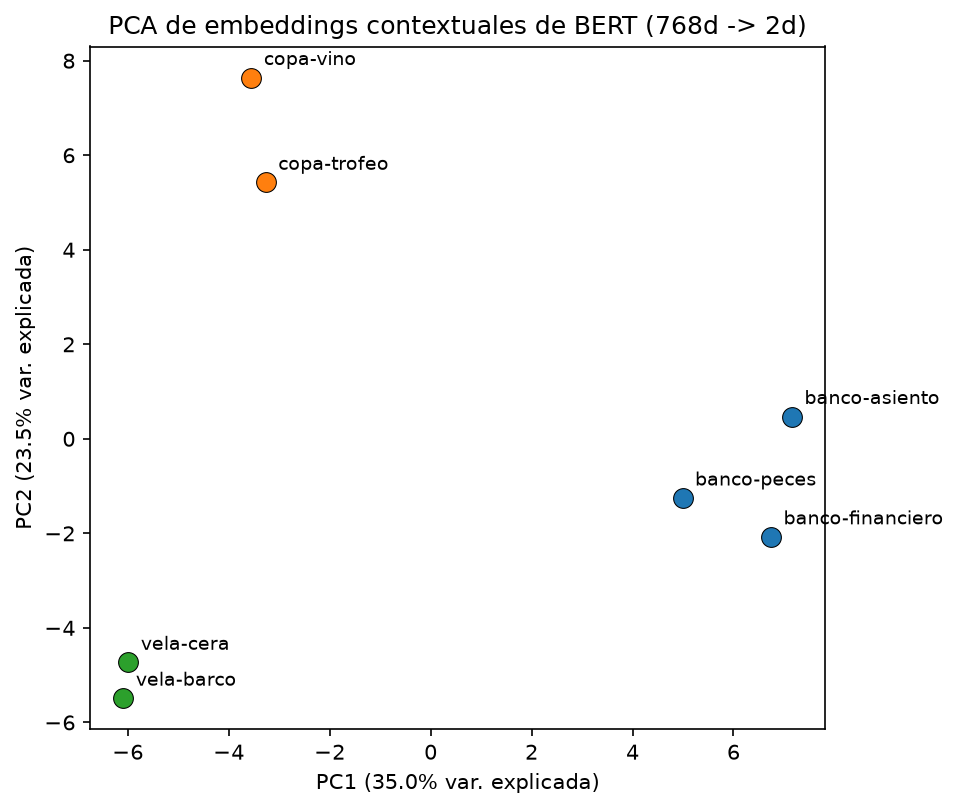

In [21]:
senses_order = [sense for _, _, sense in examples]
words_order = [word for _, word, _ in examples]
X = torch.stack([embeddings[s] for s in senses_order]).numpy()

# Reduce los 768 componentes de BERT a las 2 direcciones de mayor varianza entre
# estas 7 instancias, únicamente para poder graficarlas en el plano.
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

color_by_word = {"banco": "tab:blue", "copa": "tab:orange", "vela": "tab:green"}

plt.figure(figsize=(6.5, 5.5))
for (x, y), sense, word in zip(coords, senses_order, words_order):
    plt.scatter(x, y, color=color_by_word[word], s=90, edgecolor="black", linewidth=0.5)
    plt.annotate(sense, (x, y), textcoords="offset points", xytext=(6, 6), fontsize=9)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var. explicada)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var. explicada)")
plt.title("PCA de embeddings contextuales de BERT (768d -> 2d)")
plt.tight_layout()
plt.savefig("bert_pca.png", dpi=150)
plt.show()

print("Coordenadas PCA:")
for sense, (x, y) in zip(senses_order, coords):
    print(f"  {sense:<18} ({x:7.3f}, {y:7.3f})")


**Discusión 3.2.c:**

Coordenadas obtenidas (PC1, PC2):

| Sentido | PC1 | PC2 |
|---|---|---|
| banco-financiero | 6.745 | -2.074 |
| banco-asiento | 7.159 | 0.472 |
| banco-peces | 4.991 | -1.252 |
| copa-trofeo | -3.267 | 5.426 |
| copa-vino | -3.551 | 7.644 |
| vela-barco | -6.088 | -5.488 |
| vela-cera | -5.989 | -4.729 |

Los tres grupos de palabra quedan en regiones completamente separadas del plano: el centroide de `banco` está en aproximadamente (6.30, -0.95), el de `copa` en (-3.41, 6.54) y el de `vela` en (-6.04, -5.11). Las distancias euclidianas **entre** centroides de palabras distintas son de ~12-13 unidades, mientras que la distancia **entre** las dos instancias más alejadas de un mismo grupo (`banco-asiento` vs. `banco-peces`) es de solo ~2.77 unidades — casi un orden de magnitud menor.

En otras palabras: **la identidad léxica de la palabra domina la proyección** (los tres sentidos de "banco" quedan todos del mismo lado del plano, lejos de "copa" y "vela"), pero dentro de cada grupo sí hay una dispersión secundaria y real que refleja el sentido: `banco-peces` es el punto más alejado de los otros dos sentidos de "banco" (distancias de 1.94 y 2.77 frente a 2.58 entre `banco-financiero` y `banco-asiento`), consistente con que su similitud coseno con `banco-asiento` (0.6496) es ligeramente menor que la de `banco-financiero` con `banco-peces` (0.6603). Es decir: **los contextos distintos de la misma palabra no llegan a separarse en regiones completamente distintas del espacio** (seguirían siendo reconocibles como instancias de "banco", "copa" o "vela" por su cercanía mutua), pero tampoco colapsan en un único punto: hay una dispersión fina dentro de cada grupo que SÍ codifica diferencias de sentido, montada sobre una dispersión mucho más grande que separa las palabras entre sí.